IT25101505_Normalization_Scaling

FAIJ AHAMED M.L. — Individual Preprocessing Component

Technique: Normalization / Feature Scaling

Why this technique was needed
The dataset mixes features on very different scales — e.g. age (18-90), hba1c (4-10),
insulin_level (2-33), and physical_activity_minutes_per_week (0-300+). Distance-based
models such as KNN (the group's chosen classifier) compute Euclidean distance between
points, so a large-range feature like physical_activity_minutes_per_week would dominate the
distance calculation and drown out a clinically important but small-range feature like hba1c
unless every feature is put on a comparable scale first.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [7]:
df = pd.read_csv('../results/outputs/stage3_outliers_capped.csv')
print(df.shape)

(97297, 41)


In [8]:
select =df.select_dtypes(include=[np.number])
numeric_cols = select.columns.tolist()
# exclude the target and target-derived / leakage columns from scaling comparison
exclude = ['diabetes_stage_encoded', 'diagnosed_diabetes', 'diabetes_risk_score']
numeric_cols = [c for c in numeric_cols if c not in exclude]
print(f"{len(numeric_cols)} numeric feature columns to scale")

25 numeric feature columns to scale


In [9]:
df[numeric_cols].describe().T[['min','max','mean','std']].head(10)

,min,max,mean,std
Age,19.0,90.0,50.192699,15.492557
education_level,0.0,3.0,1.598210,0.801376
income_level,0.0,4.0,1.750691,1.086620
smoking_status,0.0,2.0,0.602999,0.801313
alcohol_consumption_per_week,0.0,6.0,1.998828,1.398846
physical_activity_minutes_per_week,0.0,314.5,116.767562,77.362637
diet_score,0.0,10.0,5.995214,1.780096
sleep_hours_per_day,3.0,10.0,6.997708,1.093726
screen_time_hours_per_day,0.5,16.8,5.997031,2.469805
family_history_diabetes,0.0,1.0,0.219657,0.414017


Step 1 — Compare raw scale ranges across a few representative columns

In [10]:
compare_cols = ['age' if 'age' in df.columns else 'Age', 'hba1c', 'insulin_level',
                 'physical_activity_minutes_per_week', 'cholesterol_total']
compare_cols = [c for c in compare_cols if c in df.columns]
ranges = df[compare_cols].agg(['min', 'max']).T
ranges['range'] = ranges['max'] - ranges['min']
ranges.sort_values('range', ascending=False)

,min,max,range
physical_activity_minutes_per_week,0.00,314.50,314.50
cholesterol_total,100.00,274.00,174.00
Age,19.00,90.00,71.00
insulin_level,2.00,23.49,21.49
hba1c,4.32,8.72,4.40


Step 2 — Apply StandardScaler (like z-score) and MinMaxScaler, and compare

In [11]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

In [12]:
df_std = df.copy()
df_std[numeric_cols] = std_scaler.fit_transform(df[numeric_cols])

In [13]:
df_minmax = df.copy()
df_minmax[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

In [14]:
df_std[compare_cols].describe().T[['min','max','mean','std']]

,min,max,mean,std
Age,-2.013409,2.569460,1.840311e-16,1.000005
hba1c,-2.716383,2.716590,1.210808e-16,1.000005
insulin_level,-1.428948,2.921658,1.183057e-17,1.000005
physical_activity_minutes_per_week,-1.509361,2.555930,1.168452e-17,1.000005
cholesterol_total,-2.692651,2.758194,2.009737e-16,1.000005


EDA Visualization — Distribution before vs. after scaling

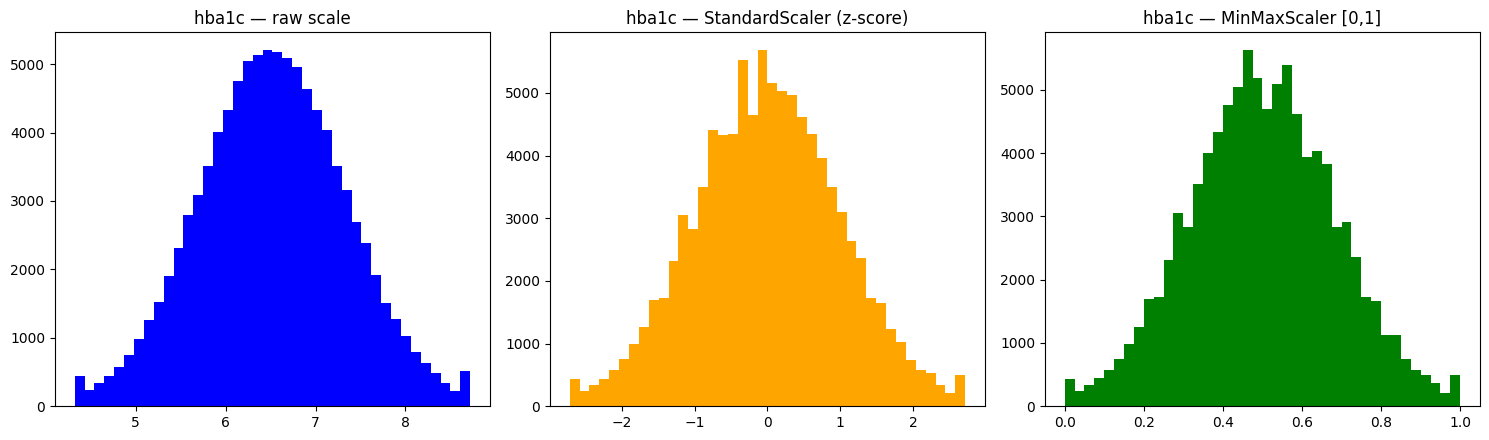

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].hist(df['hba1c'], bins=40, color='blue')
axes[0].set_title('hba1c — raw scale')

axes[1].hist(df_std['hba1c'], bins=40, color='orange')
axes[1].set_title('hba1c — StandardScaler (z-score)')

axes[2].hist(df_minmax['hba1c'], bins=40, color='green')
axes[2].set_title('hba1c — MinMaxScaler [0,1]')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/scaling_comparison.png', dpi=120)
plt.show()

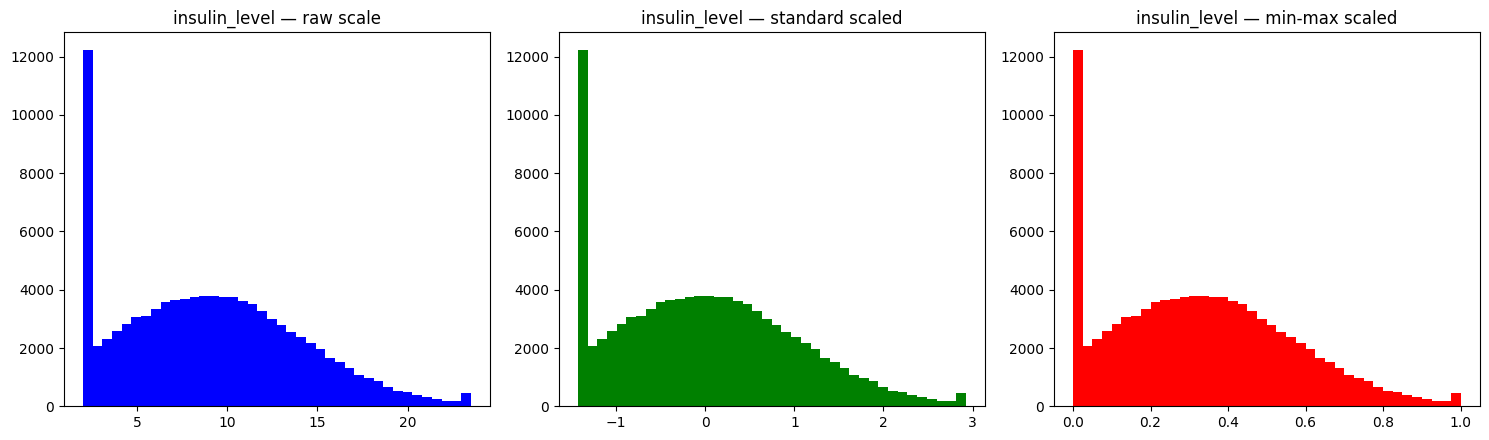

In [19]:
fig, axes1 = plt.subplots(1, 3, figsize=(15, 4.5))
axes1[0].hist(df['insulin_level'], bins=40, color='blue')
axes1[0].set_title('insulin_level — raw scale')
axes1[1].hist(df_std['insulin_level'], bins=40, color='green')
axes1[1].set_title('insulin_level — standard scaled')
axes1[2].hist(df_minmax['insulin_level'], bins=40, color='red')
axes1[2].set_title('insulin_level — min-max scaled')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/scaling_comparison_insulin.png', dpi=120)
plt.show()

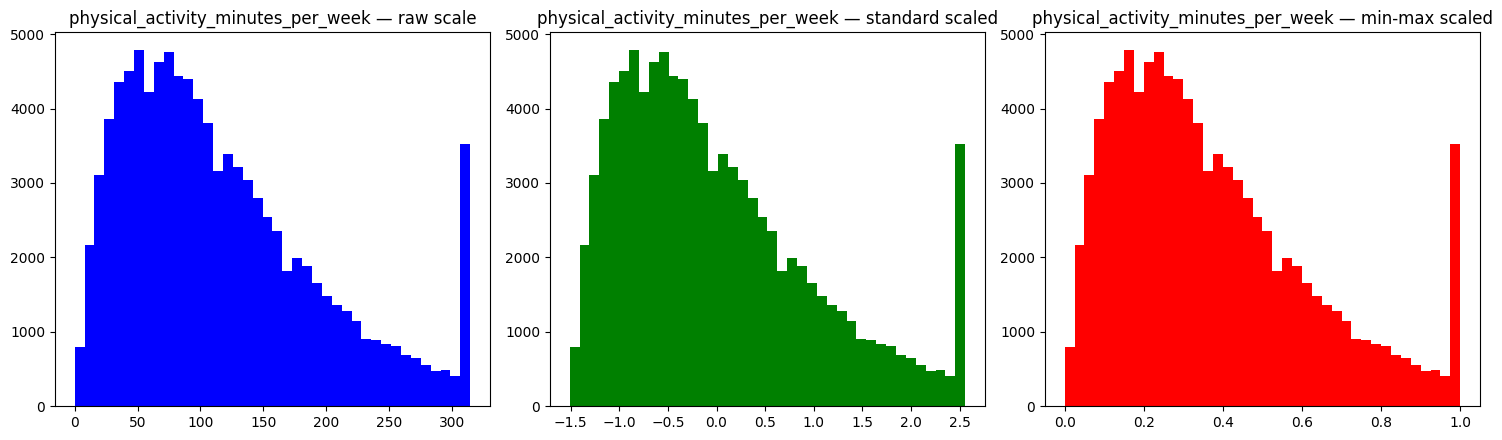

In [20]:
fig, axes2 = plt.subplots(1, 3, figsize=(15, 4.5))
axes2[0].hist(df['physical_activity_minutes_per_week'], bins=40, color='blue')
axes2[0].set_title('physical_activity_minutes_per_week — raw scale')
axes2[1].hist(df_std['physical_activity_minutes_per_week'], bins=40, color='green')
axes2[1].set_title('physical_activity_minutes_per_week — standard scaled')
axes2[2].hist(df_minmax['physical_activity_minutes_per_week'], bins=40, color='red')
axes2[2].set_title('physical_activity_minutes_per_week — min-max scaled')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/scaling_comparison_physical_activity.png', dpi=120)
plt.show()

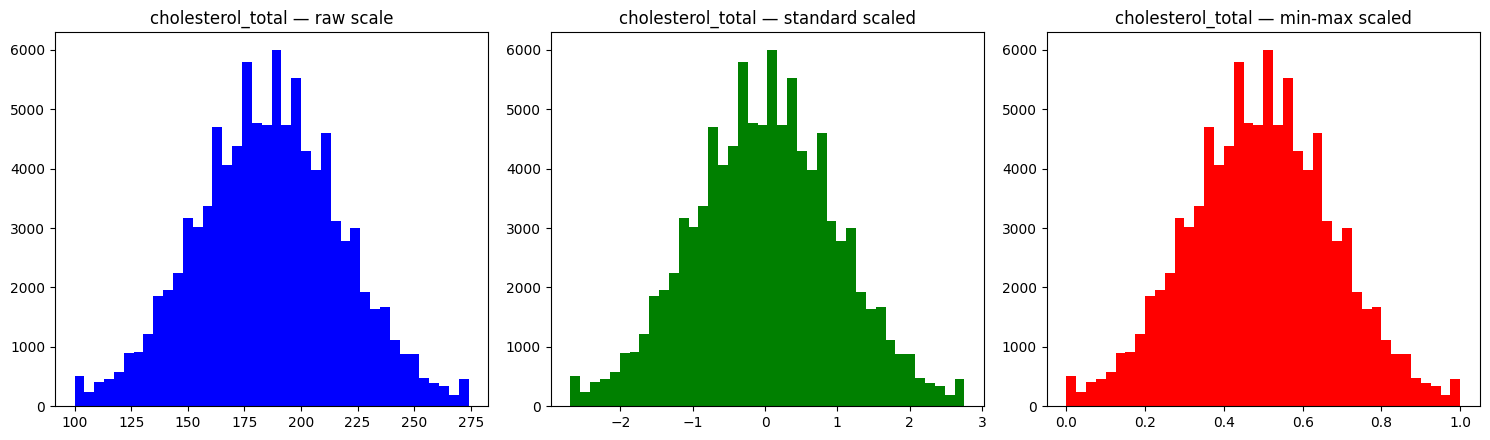

In [25]:
fig, axes4 = plt.subplots(1, 3, figsize=(15, 4.5))
axes4[0].hist(df['cholesterol_total'], bins=40, color='blue')
axes4[0].set_title('cholesterol_total — raw scale')

axes4[1].hist(df_std['cholesterol_total'], bins=40, color='green')
axes4[1].set_title('cholesterol_total — standard scaled')

axes4[2].hist(df_minmax['cholesterol_total'], bins=40, color='red')
axes4[2].set_title('cholesterol_total — min-max scaled')

plt.tight_layout()
plt.savefig('../results/eda_visualizations/scaling_comparison_cholesterol.png', dpi=120)
plt.show()

C:\Users\faij ahamed\AppData\Local\Temp\ipykernel_2020\4002099778.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[c] for c in compare_cols], labels=compare_cols, patch_artist=True,


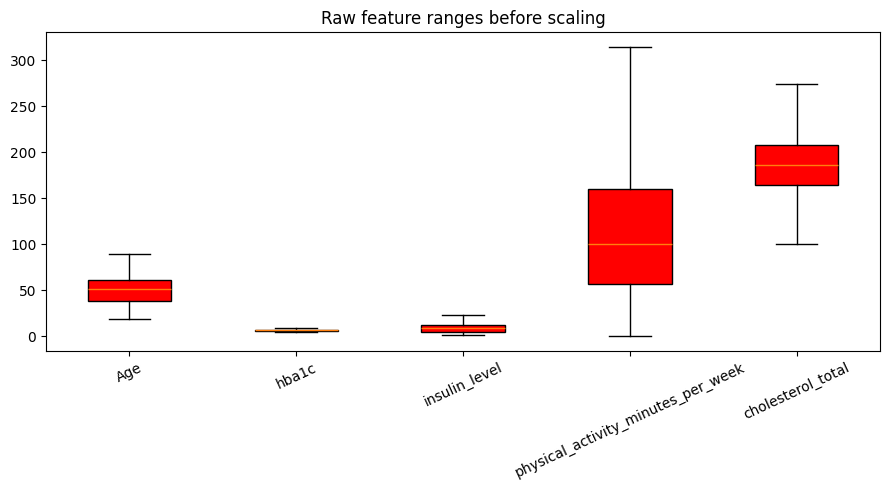

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([df[c] for c in compare_cols], labels=compare_cols, patch_artist=True,
           boxprops=dict(facecolor='red'))
ax.set_title('Raw feature ranges before scaling')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.savefig('../results/eda_visualizations/pre_scaling_ranges.png', dpi=120)
plt.show()

C:\Users\faij ahamed\AppData\Local\Temp\ipykernel_2020\4084166177.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(scaled_data,labels=compare_cols, patch_artist=True, boxprops=dict(facecolor='green'))


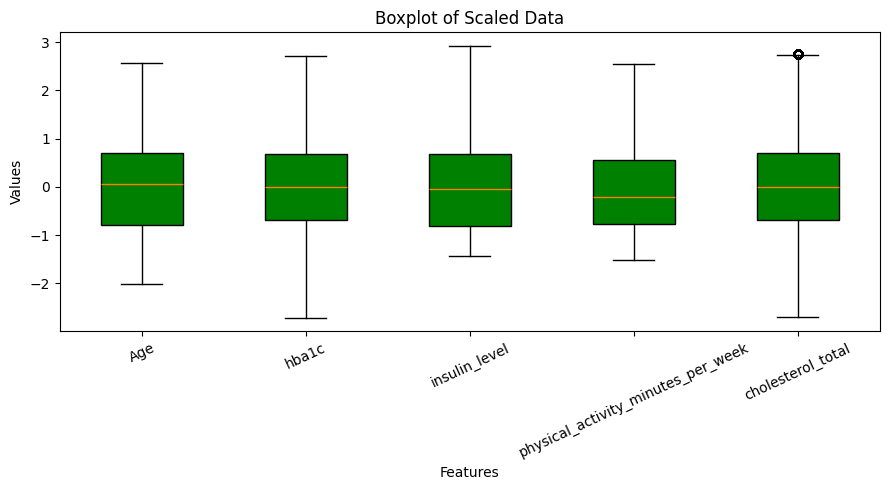

In [29]:
#after scaling boxplots
fig, ax = plt.subplots(figsize=(9, 5))
scaled_data = [df_std[c] for c in compare_cols]
ax.boxplot(scaled_data,labels=compare_cols, patch_artist=True, boxprops=dict(facecolor='green'))
ax.set_title('Boxplot of Scaled Data')
ax.set_xlabel('Features')
ax.set_ylabel('Values')

plt.xticks(ticks=range(1, len(compare_cols) + 1), labels=compare_cols, rotation=25)
plt.tight_layout()
plt.savefig('../results/eda_visualizations/post_scaling_ranges.png', dpi=120)
plt.show()

Interpretation
The raw-scale boxplot shows features occupying wildly different ranges — exactly the situation
that would bias a KNN distance calculation toward
physical_activity_minutes_per_week/cholesterol_total and away from hba1c. The histogram
shows the shape of the hba1c distribution is identical after scaling — only the x-axis
units change — confirming scaling does not distort the underlying data, it only re-centers/
re-ranges it.

Step 3 — Choice: StandardScaler for the group pipeline
StandardScaler (mean = 0, std = 1) was chosen over MinMaxScaler because:
It is less sensitive to the exact min/max bound of a column (relevant since Member 3's
   capping step already bounded outliers rather than removing them).
KNN and most scikit-learn classifiers are typically validated with standardized rather than
   min-max-scaled features in practice.

In [28]:
df_std.to_csv('../results/outputs/stage4_scaled.csv', index=False)
print("Saved scaled dataset for the group pipeline:", df_std.shape)

Saved scaled dataset for the group pipeline: (97297, 41)
